In [2]:
import json
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# 1. Carica tracks.json
with open('tracks.json', encoding='utf-8') as f:
    tracks = json.load(f)
df_tracks = pd.DataFrame(tracks)



In [6]:
# 2. Carica artists.xml
tree = ET.parse('artists.xml')
root = tree.getroot()
artists = []
for row in root.findall('row'):
    artists.append({elem.tag: elem.text for elem in row})
df_artists = pd.DataFrame(artists)



In [7]:
df_tracks.describe(include="all")


,id,id_artist,title,featured_artists,primary_artist,language,album,swear_IT,swear_EN,swear_IT_words,...,album_release_date,album_type,disc_number,track_number,duration_ms,explicit,popularity,id_album,lyrics,streams@1month
count,11166,11166,11166,3517,11166,11061,9652,11166.000000,11166.000000,11166,...,11088,11088,11088.000000,11088.000000,1.108800e+04,11088,11088.000000,11088,11163,1.116600e+04
unique,11093,104,10521,1740,104,35,890,NaN,NaN,2659,...,1390,3,NaN,NaN,NaN,2,NaN,3061,11153,NaN
top,TR367132,ART91352277,Intro,Guè,Mondo Marcio,it,Rimo Da Quando,NaN,NaN,[],...,2025-04-10,album,NaN,NaN,NaN,True,NaN,ALB441104,E visto che non so dire di no\nSintomi da star...,NaN
freq,4,353,36,64,353,9352,47,NaN,NaN,4176,...,134,9353,NaN,NaN,NaN,5629,NaN,48,2,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.343006,0.711177,NaN,...,NaN,NaN,1.016685,6.859127,2.035293e+05,NaN,32.656295,NaN,NaN,1.821737e+04
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.704831,2.555423,NaN,...,NaN,NaN,0.138903,5.191472,8.825641e+04,NaN,19.781473,NaN,NaN,3.903201e+04
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,...,NaN,NaN,1.000000,1.000000,1.142600e+04,NaN,0.000000,NaN,NaN,4.011000e+03
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,...,NaN,NaN,1.000000,2.000000,1.701310e+05,NaN,16.000000,NaN,NaN,4.835000e+03
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,...,NaN,NaN,1.000000,6.000000,1.966725e+05,NaN,32.000000,NaN,NaN,5.644500e+03
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,...,NaN,NaN,1.000000,10.000000,2.271840e+05,NaN,47.000000,NaN,NaN,1.423925e+04


In [8]:
df_artists.describe(include="all")


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
count,104,104,104,73,72,71,86,50,0,70,68,70,72,72
unique,104,104,2,73,40,2,69,24,0,26,13,1,40,40
top,ART82291002,99 posse,M,1990-07-11,Milano,Italia,gruppo musicale italiano,1996-01-01,NaN,Milano,Lombardia,Italia,45.4641943,9.1896346
freq,1,1,87,1,15,70,6,6,NaN,19,24,70,15,15


In [9]:
print(df_tracks.duplicated().sum())
print(df_artists.duplicated().sum())




0
0


In [12]:
#contiamo quante colonne hanno valori nulli
print(df_tracks.isnull().sum())
print(df_artists.isnull().sum())

id                         0
id_artist                  0
title                      0
featured_artists        7649
primary_artist             0
language                 105
album                   1514
swear_IT                   0
swear_EN                   0
swear_IT_words             0
swear_EN_words             0
year                     444
month                   1197
day                     1323
n_sentences               76
n_tokens                  76
char_per_tok              76
avg_token_per_clause      76
bpm                       64
rolloff                   64
flux                      64
rms                       64
flatness                  64
spectral_complexity       64
pitch                     64
loudness                  64
album_name                78
album_release_date        78
album_type                78
disc_number               78
track_number              78
duration_ms               78
explicit                  78
popularity                78
id_album      

In [13]:
#calcoliamo le percentuali di valori nulli per colonne
missing_tracks = (df_tracks.isnull().mean() * 100).round(2)
missing_tracks = missing_tracks[missing_tracks > 0].sort_values(ascending=False)

missing_tracks
#per i valori sotto l'1 autofill, il resto lo cerchiamo

featured_artists        68.50
album                   13.56
day                     11.85
month                   10.72
year                     3.98
language                 0.94
explicit                 0.70
album_type               0.70
disc_number              0.70
track_number             0.70
duration_ms              0.70
album_name               0.70
popularity               0.70
id_album                 0.70
album_release_date       0.70
char_per_tok             0.68
n_tokens                 0.68
n_sentences              0.68
avg_token_per_clause     0.68
flatness                 0.57
loudness                 0.57
pitch                    0.57
spectral_complexity      0.57
rms                      0.57
flux                     0.57
rolloff                  0.57
bpm                      0.57
lyrics                   0.03
dtype: float64

In [16]:
#e adesso per il file artists
df_artists.replace('', pd.NA, inplace=True)
missing_artists = (df_artists.isnull().mean() * 100).round(2)
missing_artists = missing_artists[missing_artists > 0].sort_values(ascending=False)

missing_artists


active_end      100.00
active_start     51.92
region           34.62
province         32.69
country          32.69
nationality      31.73
birth_place      30.77
latitude         30.77
longitude        30.77
birth_date       29.81
description      17.31
dtype: float64

In [12]:
#potremmo fillare i dati mancando usando apis da spotify, wikidata ecc ma non sarebbe uno sforzo reasonable

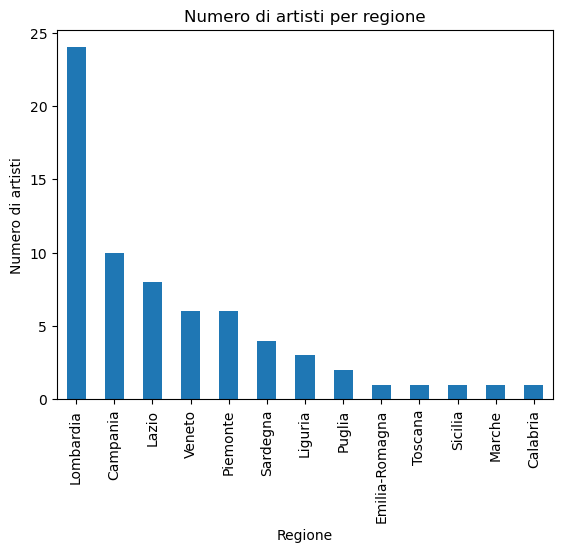

In [24]:
artists_per_region = df_artists['region'].value_counts()

#plottiamo un istogramma per vedere la distribuzione geografica degli artisti
plt.figure()
artists_per_region.plot(kind='bar')

plt.xlabel('Regione')
plt.ylabel('Numero di artisti')
plt.title('Numero di artisti per regione')

plt.show()

In [ ]:
#tramite le variabili che abbiamo potremmo crearne altre per trarre nuove informazioni
df_tracks['aggressiveness'] = df_tracks['loudness'] + df_tracks['bpm']
debut = pd.to_datetime(df_artists['active_start'], errors='coerce') - \
        pd.to_datetime(df_artists['birth_date'], errors='coerce')

df_artists['debut_age'] = debut.dt.days / 365.25


In [ ]:
#variabile fortemene sbilanciata
print(df_tracks['disc_number'].nunique())
round((df_tracks['disc_number'] == 1).mean() * 100, 2)